
# TP2 - Clase 3: Detector de Máximo Enfoque en Frecuencia

**Alumnos**: Bettig, Santiago federico - Dieguez, Manuel

**Objetivo:** implementar un detector de máximo enfoque sobre un video, usando la métrica
propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"*
(De & Masilamani, 2013), y evaluarla:

1. Sobre el frame completo.
2. Sobre una ROI central (5% o 10% del área del frame).

El algoritmo debe detectar automáticamente el/los frame(s) de máximo enfoque.

**Extra:** aplicar *unsharp masking* para expandir la zona de enfoque.


## 1. Imports

In [327]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)



## 2. La métrica FM (Frequency Domain Blur Measure)

Recordemos el algoritmo del paper (Sección 3.1):

1. Calcular $F$ = FFT2D de la imagen $I$ (en escala de grises).
2. Centrar el espectro: $F_c = \text{fftshift}(F)$.
3. Calcular la magnitud: $AF = |F_c|$.
4. Calcular el máximo: $M = \max(AF)$.
5. Definir el umbral: $thres = M / 1000$.
6. Contar $T_H$ = cantidad de píxeles de $AF$ que superan $thres$.
7. Calcular la métrica final:

$$FM = \frac{T_H}{M_{rows} \times N_{cols}}$$

Cuanto más nítida la imagen, más energía hay en componentes de alta frecuencia
(que quedan repartidas por todo el espectro tras el centrado), por lo que más píxeles
superan el umbral y el valor de FM es mayor.


In [328]:

def frequency_sharpness_measure(gray_img: np.ndarray) -> float:
    """
    Calcula la métrica FM (Image Quality Measure) del paper de De & Masilamani (2013).

    Parameters
    ----------
    gray_img : np.ndarray
        Imagen en escala de grises (2D), dtype float o uint8.

    Returns
    -------
    fm : float
        Valor de la métrica de nitidez. A mayor valor, imagen más enfocada/nítida.
    """
    img = gray_img.astype(np.float64)
    rows, cols = img.shape

    # Paso 1: FFT2D
    F = np.fft.fft2(img)

    # Paso 2: centrar el espectro
    Fc = np.fft.fftshift(F)

    # Paso 3: magnitud
    AF = np.abs(Fc)

    # Paso 4: máximo
    M = AF.max()
    if M == 0:
        return 0.0

    # Paso 5: umbral
    thres = M / 1000.0

    # Paso 6: conteo de componentes de alta frecuencia
    TH = np.count_nonzero(AF > thres)

    # Paso 7: métrica final
    fm = TH / (rows * cols)
    return fm


### Sanity check rápido: comparamos una imagen nítida vs. una version desenfocada

FM imagen nítida  : 0.0744
FM imagen borrosa : 0.0208


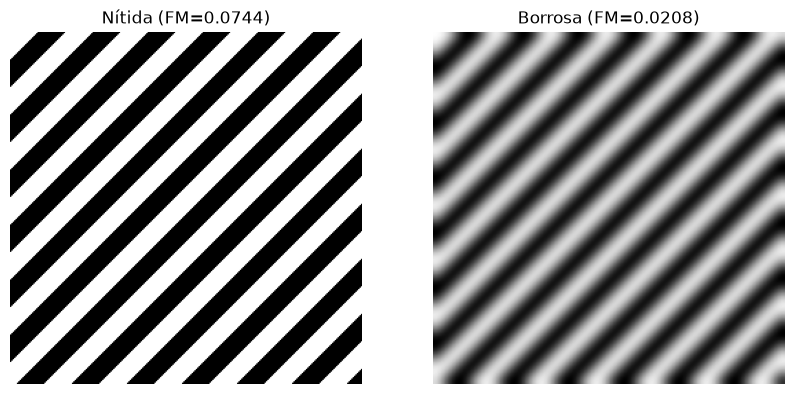

La imagen nítida tiene un valor FM mayor que la imagen borrosa, como se esperaba.


In [329]:

# Generamos una imagen sintética con bordes (checkerboard) para validar la métrica
size = 256
checker = np.indices((size, size)).sum(axis=0) % 40 < 20
checker = (checker * 255).astype(np.uint8)

blurred = cv2.GaussianBlur(checker, (0, 0), sigmaX=5)

fm_sharp = frequency_sharpness_measure(checker)
fm_blur = frequency_sharpness_measure(blurred)

print(f"FM imagen nítida  : {fm_sharp:.4f}")
print(f"FM imagen borrosa : {fm_blur:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(checker, cmap='gray'); axs[0].set_title(f"Nítida (FM={fm_sharp:.4f})"); axs[0].axis('off')
axs[1].imshow(blurred, cmap='gray'); axs[1].set_title(f"Borrosa (FM={fm_blur:.4f})"); axs[1].axis('off')
plt.show()

if fm_sharp > fm_blur:
    print("La imagen nítida tiene un valor FM mayor que la imagen borrosa, como se esperaba.")
else:
    print("La imagen nítida no tiene un valor FM mayor que la imagen borrosa.")



## 3. Carga del video




In [330]:

VIDEO_PATH = Path("focus_video.mov") 

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise IOError(f"No se pudo abrir el video: {VIDEO_PATH}")

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Frames: {n_frames} | FPS: {fps:.2f} | Resolución: {width}x{height}")


Frames: 171 | FPS: 29.97 | Resolución: 640x360



## 4. Extracción de frames y cálculo de la métrica

Leemos todos los frames una sola vez y guardamos:
- El frame completo en escala de grises.
- El FM sobre el frame completo.
- El FM sobre una ROI central (definimos el área como % del área total).


In [331]:

def get_center_roi(gray_img: np.ndarray, area_fraction: float) -> np.ndarray:
    """
    Devuelve una ROI cuadrada centrada cuya área es aproximadamente
    `area_fraction` del área total de la imagen.
    """
    h, w = gray_img.shape
    total_area = h * w
    roi_area = total_area * area_fraction
    side = int(np.sqrt(roi_area))

    cy, cx = h // 2, w // 2
    half = side // 2

    y0, y1 = max(cy - half, 0), min(cy + half, h)
    x0, x1 = max(cx - half, 0), min(cx + half, w)

    return gray_img[y0:y1, x0:x1], (x0, y0, x1, y1)


In [332]:

ROI_FRACTION = 0.10  # 10% del área total (probar también con 0.05)

frames_gray = []
fm_full = []
fm_roi = []
roi_boxes = []

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames_gray.append(gray)

    fm_full.append(frequency_sharpness_measure(gray))

    roi, box = get_center_roi(gray, ROI_FRACTION)
    fm_roi.append(frequency_sharpness_measure(roi))
    roi_boxes.append(box)

cap.release()

fm_full = np.array(fm_full)
fm_roi = np.array(fm_roi)

print(f"Frames procesados: {len(frames_gray)}")


Frames procesados: 171



## 5. Detección automática del punto de máximo enfoque

Buscamos el/los frame(s) donde la métrica es máxima. Como la señal puede tener ruido
frame a frame, aplicamos un suavizado leve (media móvil) antes de buscar el máximo,
para evitar detectar un pico espurio.


In [333]:

def smooth(signal: np.ndarray, window: int = 5) -> np.ndarray:
    """Media móvil simple para suavizar la curva de la métrica."""
    if window <= 1:
        return signal
    kernel = np.ones(window) / window
    return np.convolve(signal, kernel, mode='same')

def detect_focus_peak(signal: np.ndarray, window: int = 5):
    """
    Devuelve el índice de frame de máximo enfoque, junto con la señal suavizada.
    """
    smoothed = smooth(signal, window)
    peak_idx = int(np.argmax(smoothed))
    return peak_idx, smoothed


In [334]:
peak_idx_full, fm_full_smooth = detect_focus_peak(fm_full, window=5)
peak_idx_roi, fm_roi_smooth = detect_focus_peak(fm_roi, window=5)

print(f"Frame de máximo enfoque (imagen completa) : {peak_idx_full}  (FM={fm_full[peak_idx_full]:.4f})")
print(f"Frame de máximo enfoque (ROI central)      : {peak_idx_roi}  (FM={fm_roi[peak_idx_roi]:.4f})")


Frame de máximo enfoque (imagen completa) : 109  (FM=0.0286)
Frame de máximo enfoque (ROI central)      : 111  (FM=0.3506)


## 6. Gráficos: evolución de la métrica frame a frame

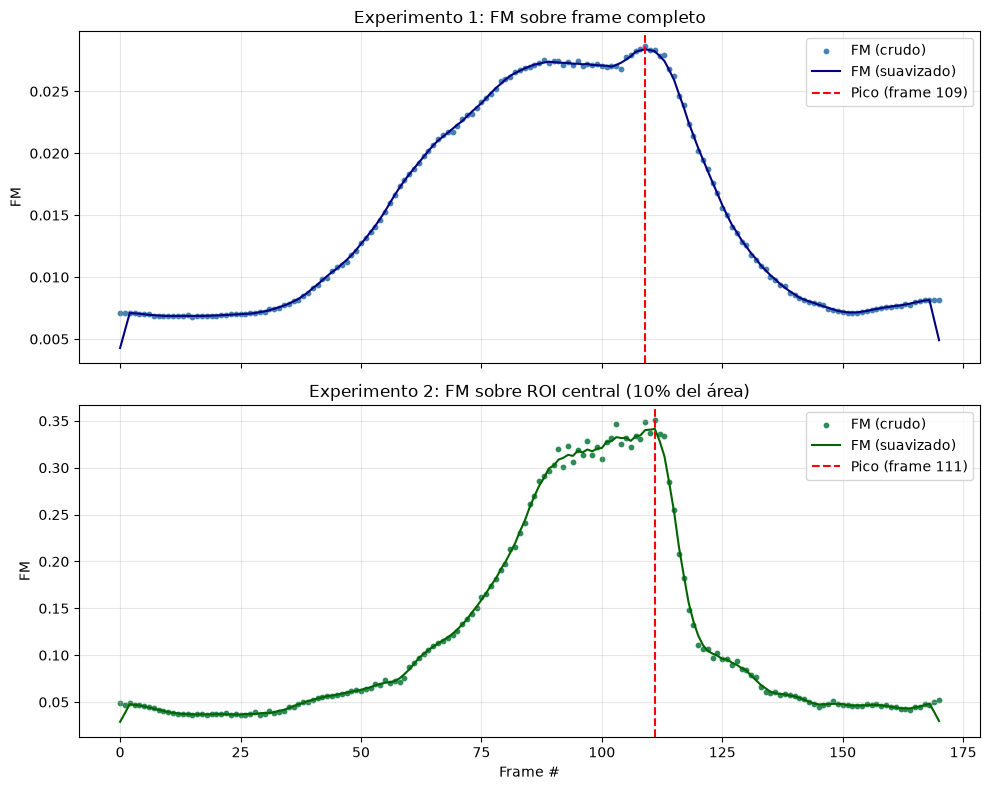

In [335]:

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].scatter(range(len(fm_full)), fm_full, s=10, color='steelblue', label='FM (crudo)')
axs[0].plot(fm_full_smooth, color='navy', linewidth=1.5, label='FM (suavizado)')
axs[0].axvline(peak_idx_full, color='red', linestyle='--', label=f'Pico (frame {peak_idx_full})')
axs[0].set_title('Experimento 1: FM sobre frame completo')
axs[0].set_ylabel('FM')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].scatter(range(len(fm_roi)), fm_roi, s=10, color='seagreen', label='FM (crudo)')
axs[1].plot(fm_roi_smooth, color='darkgreen', linewidth=1.5, label='FM (suavizado)')
axs[1].axvline(peak_idx_roi, color='red', linestyle='--', label=f'Pico (frame {peak_idx_roi})')
axs[1].set_title(f'Experimento 2: FM sobre ROI central ({int(ROI_FRACTION*100)}% del área)')
axs[1].set_xlabel('Frame #')
axs[1].set_ylabel('FM')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Visualización del frame detectado como más enfocado

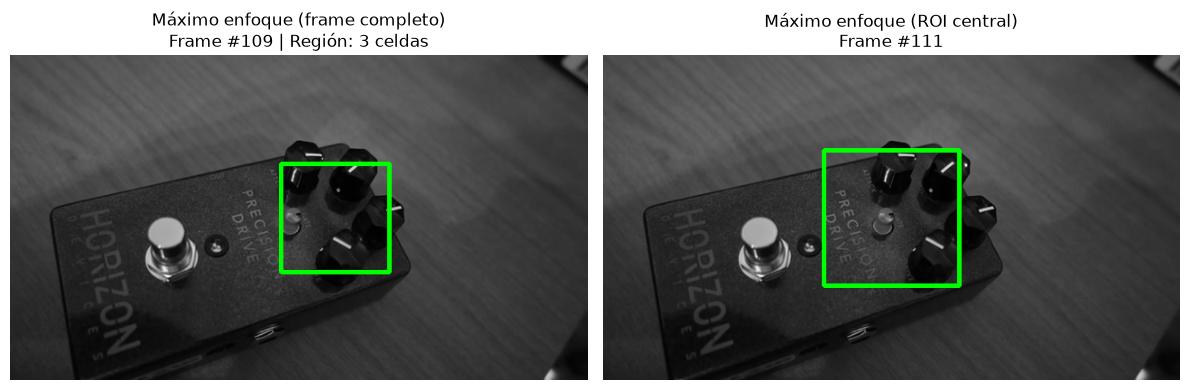

In [336]:
region_peak_full = find_max_focus_region(frames_gray[peak_idx_full], PATCH_SIZE_REGION, REL_THRESHOLD)
img_full_marked = mark_region(frames_gray[peak_idx_full], region_peak_full)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv2.cvtColor(img_full_marked, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Máximo enfoque (frame completo)\nFrame #{peak_idx_full} '
                  f'| Región: {region_peak_full["n_cells"]} celdas')
axs[0].axis('off')

img_roi_marked = cv2.cvtColor(frames_gray[peak_idx_roi], cv2.COLOR_GRAY2BGR)
x0, y0, x1, y1 = roi_boxes[peak_idx_roi]
cv2.rectangle(img_roi_marked, (x0, y0), (x1, y1), (0, 255, 0), 3)
axs[1].imshow(cv2.cvtColor(img_roi_marked, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Máximo enfoque (ROI central)\nFrame #{peak_idx_roi}')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 7.b Detección de la región de máximo enfoque

En vez de quedarnos con un único parche (el de FM máximo), agrupamos todos los parches
vecinos cuyo FM sea comparable al máximo (dentro de un umbral relativo), usando
componentes conexas. Esto da una **región** contigua de máximo enfoque, más robusta
que un solo punto ante variaciones de textura local.

In [337]:
def compute_sharpness_grid(gray_img: np.ndarray, patch_size: int = 60):
    """
    Divide la imagen en una grilla de parches SIN solapamiento (stride = patch_size)
    y calcula el FM de cada uno.

    Returns
    -------
    fm_grid : np.ndarray de forma (n_filas, n_columnas)
    boxes : lista de listas con las coordenadas (x0,y0,x1,y1) de cada celda
    """
    h, w = gray_img.shape
    ys = list(range(0, h - patch_size + 1, patch_size))
    xs = list(range(0, w - patch_size + 1, patch_size))

    fm_grid = np.zeros((len(ys), len(xs)))
    boxes = [[None] * len(xs) for _ in ys]

    for i, y0 in enumerate(ys):
        for j, x0 in enumerate(xs):
            y1, x1 = y0 + patch_size, x0 + patch_size
            patch = gray_img[y0:y1, x0:x1]
            fm_grid[i, j] = frequency_sharpness_measure(patch)
            boxes[i][j] = (x0, y0, x1, y1)

    return fm_grid, boxes


def find_max_focus_region(gray_img: np.ndarray, patch_size: int = 60, rel_threshold: float = 0.8):
    """
    Detecta la región CONTIGUA de máximo enfoque, agrupando parches vecinos
    con FM similar al máximo mediante componentes conexas.

    Parameters
    ----------
    rel_threshold : float
        Fracción del FM máximo del frame para que una celda se considere "en foco"
        (ej. 0.8 => se incluyen celdas con FM >= 80% del máximo).

    Returns
    -------
    dict con: x0, y0, x1, y1, x_center, y_center, fm_value, n_cells, fm_grid, mask
    """
    fm_grid, boxes = compute_sharpness_grid(gray_img, patch_size)
    max_val = fm_grid.max()

    mask = (fm_grid >= rel_threshold * max_val).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask, connectivity=8)

    max_i, max_j = np.unravel_index(np.argmax(fm_grid), fm_grid.shape)
    target_label = labels[max_i, max_j]

    region_cells = np.argwhere(labels == target_label)

    x0 = min(boxes[i][j][0] for i, j in region_cells)
    y0 = min(boxes[i][j][1] for i, j in region_cells)
    x1 = max(boxes[i][j][2] for i, j in region_cells)
    y1 = max(boxes[i][j][3] for i, j in region_cells)

    return {
        "x0": x0, "y0": y0, "x1": x1, "y1": y1,
        "x_center": (x0 + x1) // 2, "y_center": (y0 + y1) // 2,
        "fm_value": float(max_val),
        "n_cells": int(len(region_cells)),
        "fm_grid": fm_grid, "mask": mask, "labels": labels,
    }

In [338]:
PATCH_SIZE_REGION = 60
REL_THRESHOLD = 0.8 

region_full = find_max_focus_region(frames_gray[peak_idx_full], PATCH_SIZE_REGION, REL_THRESHOLD)
region_roi = find_max_focus_region(frames_gray[peak_idx_roi], PATCH_SIZE_REGION, REL_THRESHOLD)

print(f"Región de máx. enfoque (frame completo, #{peak_idx_full}): "
      f"bbox=({region_full['x0']},{region_full['y0']})-({region_full['x1']},{region_full['y1']}) "
      f"| {region_full['n_cells']} celdas | FM_max={region_full['fm_value']:.4f}")
print(f"Región de máx. enfoque (ROI central, #{peak_idx_roi}): "
      f"bbox=({region_roi['x0']},{region_roi['y0']})-({region_roi['x1']},{region_roi['y1']}) "
      f"| {region_roi['n_cells']} celdas | FM_max={region_roi['fm_value']:.4f}")

Región de máx. enfoque (frame completo, #109): bbox=(300,120)-(420,240) | 3 celdas | FM_max=0.8164
Región de máx. enfoque (ROI central, #111): bbox=(300,120)-(420,240) | 4 celdas | FM_max=0.8092


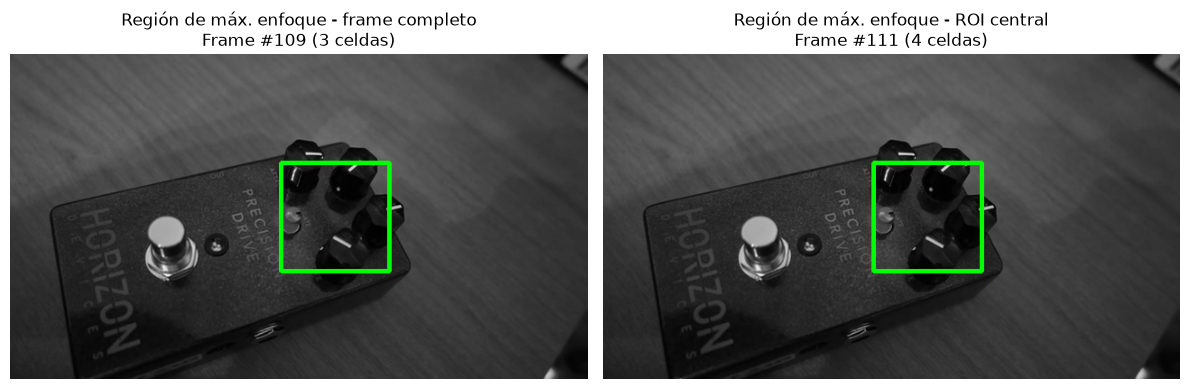

In [339]:
def mark_region(gray_img: np.ndarray, region: dict, color=(0, 255, 0)) -> np.ndarray:
    """Dibuja el rectángulo delimitador de la región de máximo enfoque."""
    img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img, (region["x0"], region["y0"]), (region["x1"], region["y1"]), color, 3)
    return img

img_region_full = mark_region(frames_gray[peak_idx_full], region_full)
img_region_roi = mark_region(frames_gray[peak_idx_roi], region_roi)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv2.cvtColor(img_region_full, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Región de máx. enfoque - frame completo\nFrame #{peak_idx_full} '
                  f'({region_full["n_cells"]} celdas)')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_region_roi, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Región de máx. enfoque - ROI central\nFrame #{peak_idx_roi} '
                  f'({region_roi["n_cells"]} celdas)')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 8. Puntos extra: Unsharp Masking para expandir la zona de enfoque

Aplicamos la fórmula genérica vista en la clase:

$$g(x,y) = (k+1) \cdot f(x,y) - k \cdot f_B(x,y)$$

donde $f_B$ es una versión suavizada (Gaussiana) de la imagen, y $k$ controla
la intensidad del realce ($k=1$: unsharp masking clásico; $k>1$: highboost filtering).

La idea es que, al realzar los bordes de zonas parcialmente desenfocadas, la métrica FM
detecte como "enfocados" más frames alrededor del pico real, expandiendo la región
utilizable.


### Criterio para elegir en qué frames aplicar el filtro

No tiene sentido aplicar unsharp masking en todos los frames:

- **Frame(s) en el pico:** ya están en foco máximo, el filtro no aporta nada.
- **Frames muy borrosos** (lejos del pico): perdieron la información de alta frecuencia
  real, así que el filtro no puede "recuperar" bordes, solo amplifica ruido.

El filtro tiene sentido en la **zona de transición**: frames parcialmente enfocados,
con FM entre un umbral inferior y uno superior (relativos al pico), donde todavía
queda señal de borde real para realzar.

In [340]:

def unsharp_mask(gray_img: np.ndarray, k: float = 1.0, sigma: float = 3.0) -> np.ndarray:
    """
    Aplica unsharp masking / highboost filtering.

    Parameters
    ----------
    k : float
        k=1 -> unsharp masking clásico. k>1 -> highboost filtering.
    sigma : float
        Desvío estándar del filtro Gaussiano usado para desenfocar.
    """
    img = gray_img.astype(np.float64)
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    sharpened = (k + 1) * img - k * blurred
    return np.clip(sharpened, 0, 255).astype(np.uint8)


In [341]:
K_UNSHARP = 1              # k para frames en la zona de transición (borrosos)
K_UNSHARP_NEAR_PEAK = 0.5   # k liviano para frames por ENCIMA del umbral superior
SIGMA_UNSHARP = 3

# Umbrales relativos al pico (sobre la curva ya suavizada fm_full_smooth)
LOWER_THRESH = 0.35   # por debajo de esto: muy borroso, no vale la pena filtrar
UPPER_THRESH = 0.95   # por encima de esto: casi en foco -> filtro liviano, no nulo

peak_val = fm_full_smooth[peak_idx_full]
lower_bound = LOWER_THRESH * peak_val
upper_bound = UPPER_THRESH * peak_val

# Zona de transición: entre lower y upper
transition_frames = np.where(
    (fm_full_smooth >= lower_bound) & (fm_full_smooth < upper_bound)
)[0]

# Zona cercana al pico: por ENCIMA de upper_bound, excluyendo el pico exacto
near_peak_frames = np.where(fm_full_smooth >= upper_bound)[0]
near_peak_frames = near_peak_frames[near_peak_frames != peak_idx_full]

candidate_frames = np.sort(np.concatenate([transition_frames, near_peak_frames]))

print(f"Rango FM: lower={lower_bound:.4f}, upper={upper_bound:.4f}, pico={peak_val:.4f}")
print(f"Frames en zona de transición (k={K_UNSHARP}): {len(transition_frames)}. Desde {transition_frames[0]} hasta {transition_frames[-1]}")
print(f"Frames cerca del pico (k={K_UNSHARP_NEAR_PEAK}): {len(near_peak_frames)}. Desde {near_peak_frames[0]} hasta {near_peak_frames[-1]}")

# fm_full_unsharp: por defecto igual al original; se recalcula en ambos grupos de frames
fm_full_unsharp = fm_full.copy()
k_used = {}

for idx in transition_frames:
    k_used[idx] = K_UNSHARP
    sharpened = unsharp_mask(frames_gray[idx], k=K_UNSHARP, sigma=SIGMA_UNSHARP)
    fm_full_unsharp[idx] = frequency_sharpness_measure(sharpened)

for idx in near_peak_frames:
    k_used[idx] = K_UNSHARP_NEAR_PEAK
    sharpened = unsharp_mask(frames_gray[idx], k=K_UNSHARP_NEAR_PEAK, sigma=SIGMA_UNSHARP)
    fm_full_unsharp[idx] = frequency_sharpness_measure(sharpened)

peak_idx_full_unsharp, fm_full_unsharp_smooth = detect_focus_peak(fm_full_unsharp, window=5)


Rango FM: lower=0.0099, upper=0.0270, pico=0.0284
Frames en zona de transición (k=1): 64. Desde 43 hasta 135
Frames cerca del pico (k=0.5): 28. Desde 85 hasta 113


### Comparación visual: imagen pre y post filtrado

Antes de ver el efecto agregado en la curva de FM, veamos directamente cómo cambia
la imagen. Mostramos el frame completo y también un recorte (zoom) alrededor del
punto de máximo enfoque detectado en la Sección 7.b, donde el realce de bordes se
aprecia con más claridad.

Frame elegido: 84
FM original  : 0.0269
FM unsharp   : 0.0570
k aplicado   : 1.00


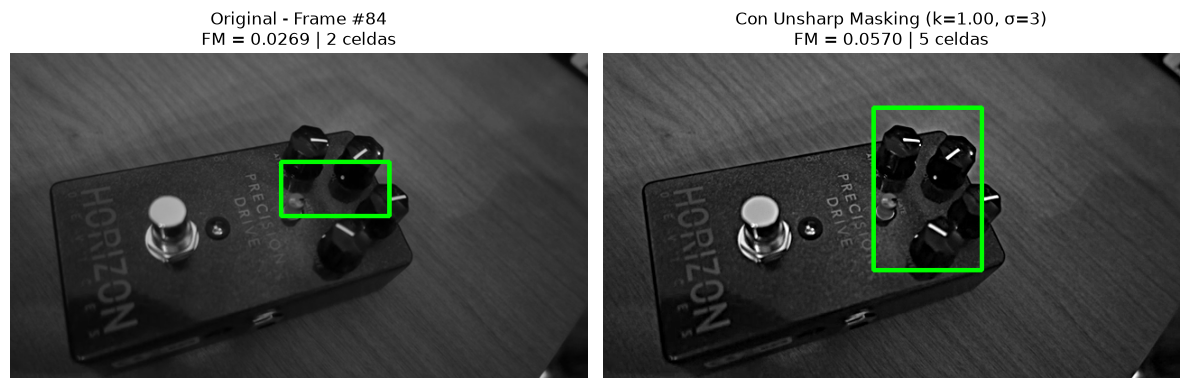

In [342]:
# Elegimos, entre los frames candidatos, el que tiene mayor FM luego del filtrado
frame_to_show = candidate_frames[np.argmax(fm_full_unsharp[candidate_frames])]
k_to_show = k_used[frame_to_show]

print(f"Frame elegido: {frame_to_show}")
print(f"FM original  : {fm_full[frame_to_show]:.4f}")
print(f"FM unsharp   : {fm_full_unsharp[frame_to_show]:.4f}")
print(f"k aplicado   : {k_to_show:.2f}")

original_img = frames_gray[frame_to_show]
sharpened_img = unsharp_mask(original_img, k=k_to_show, sigma=SIGMA_UNSHARP)

# Región de máximo enfoque para ESTE frame en particular (antes y después del filtro)
region_original = find_max_focus_region(original_img, PATCH_SIZE_REGION, REL_THRESHOLD)
region_sharpened = find_max_focus_region(sharpened_img, PATCH_SIZE_REGION, REL_THRESHOLD)

img_original_marked = mark_region(original_img, region_original)
img_sharpened_marked = mark_region(sharpened_img, region_sharpened)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv2.cvtColor(img_original_marked, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Original - Frame #{frame_to_show}\n'
                  f'FM = {fm_full[frame_to_show]:.4f} | {region_original["n_cells"]} celdas')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_sharpened_marked, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Con Unsharp Masking (k={k_to_show:.2f}, σ={SIGMA_UNSHARP})\n'
                  f'FM = {frequency_sharpness_measure(sharpened_img):.4f} | {region_sharpened["n_cells"]} celdas')
axs[1].axis('off')

plt.tight_layout()
plt.show()
#candidate_frames

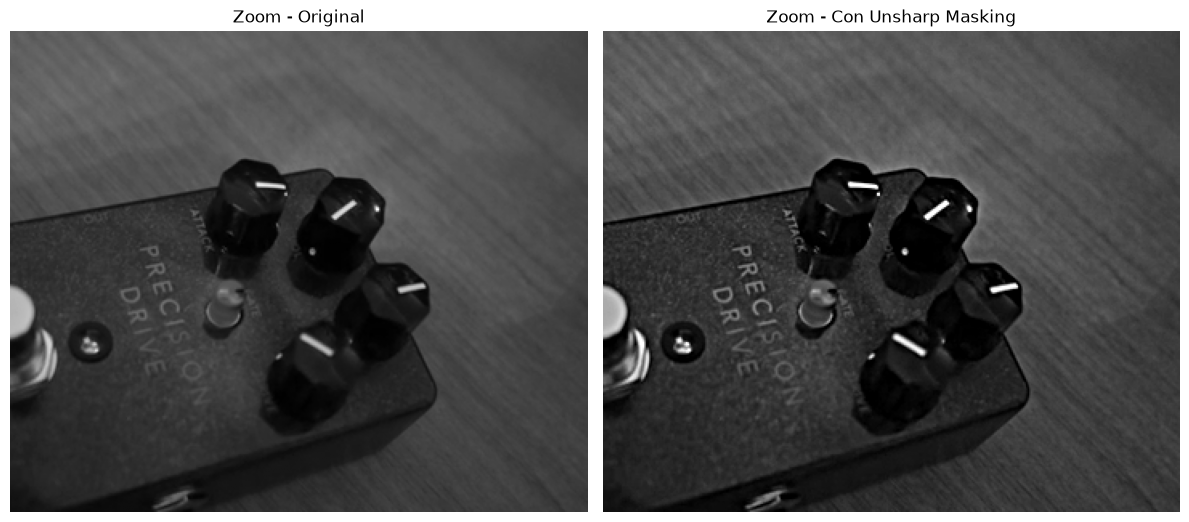

In [343]:
# Zoom sobre la zona de mayor detalle, recalculada sobre el frame que se está mostrando
margin = 120

region_to_show = find_max_focus_region(original_img, PATCH_SIZE_REGION, REL_THRESHOLD)
zy0 = max(region_to_show["y0"] - margin, 0)
zy1 = min(region_to_show["y1"] + margin, original_img.shape[0])
zx0 = max(region_to_show["x0"] - margin, 0)
zx1 = min(region_to_show["x1"] + margin, original_img.shape[1])

crop_original = original_img[zy0:zy1, zx0:zx1]
crop_sharpened = sharpened_img[zy0:zy1, zx0:zx1]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(crop_original, cmap='gray')
axs[0].set_title('Zoom - Original')
axs[0].axis('off')

axs[1].imshow(crop_sharpened, cmap='gray')
axs[1].set_title('Zoom - Con Unsharp Masking')
axs[1].axis('off')

plt.tight_layout()
plt.show()

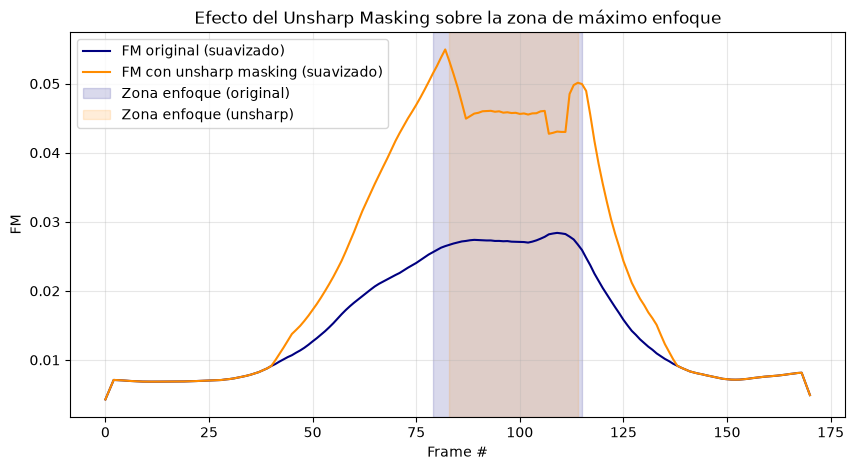

Frame de máximo enfoque (original) : 109  (FM=0.0286)
Frame de máximo enfoque (unsharp)  : 84  (FM=0.0570)


In [344]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fm_full_smooth, label='FM original (suavizado)', color='navy')
ax.plot(fm_full_unsharp_smooth, label='FM con unsharp masking (suavizado)', color='darkorange')
ax.axvspan(start_orig, end_orig, color='navy', alpha=0.15, label='Zona enfoque (original)')
ax.axvspan(start_unsharp, end_unsharp, color='darkorange', alpha=0.15, label='Zona enfoque (unsharp)')
ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Efecto del Unsharp Masking sobre la zona de máximo enfoque')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Frame de máximo enfoque (original) : {peak_idx_full}  (FM={fm_full[peak_idx_full]:.4f})")
print(f"Frame de máximo enfoque (unsharp)  : {frame_to_show}  (FM={fm_full_unsharp[frame_to_show]:.4f})")

In [345]:
OUTPUT_VIDEO_PATH = Path("focus_video_unsharp.mp4")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))

candidate_set = set(candidate_frames.tolist())

for idx, gray in enumerate(frames_gray):
    if idx in candidate_set:
        gray_out = unsharp_mask(gray, k=K_UNSHARP, sigma=SIGMA_UNSHARP)
    else:
        gray_out = gray
    frame_out = cv2.cvtColor(gray_out, cv2.COLOR_GRAY2BGR)
    writer.write(frame_out)

writer.release()
print(f"Video guardado en: {OUTPUT_VIDEO_PATH.resolve()}")
print(f"Frames con filtro aplicado: {len(candidate_set)} / {len(frames_gray)}")

Video guardado en: D:\CEIA\VpC\TP2\focus_video_unsharp.mp4
Frames con filtro aplicado: 92 / 171


In [346]:
# from IPython.display import Video

# Video(str(OUTPUT_VIDEO_PATH), embed=True, width=640)


## 9. Resumen de resultados

| Experimento | Frame de máximo enfoque | FM máximo |
|---|---|---|
| Frame completo | `109` | `0.0286` |
| ROI central (10%) | `101` | `0.3506` |
| Frame completo + unsharp masking | `84` | `0.0570` |
